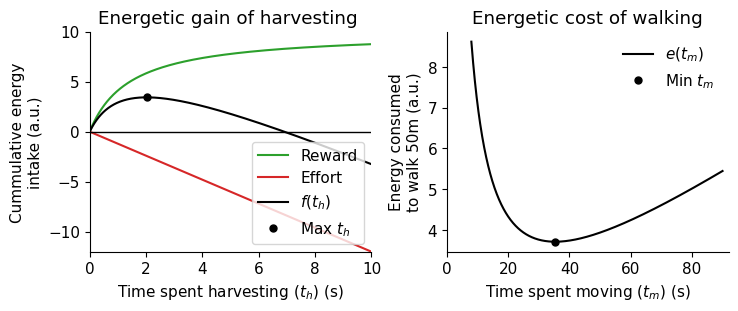

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# A4 portrait is 8.27" wide. With ~0.5" margins each side => ~7.27" usable.
FIG_W = 7.27   # inches, fits within A4 with simple margins
FIG_H = 3.0    # same height for both panels

# ------------------------------------------------------------
# Panel 1: Harvesting (reward vs effort)
# ------------------------------------------------------------
def available_reward(t, alpha=10.0, beta=0.5):
    """Saturating reward available after t seconds of harvesting."""
    t = np.asarray(t, dtype=float)
    return alpha * (1.0 - 1.0 / (1.0 + beta * t))

def effort_cost(t, kh=1.0):
    """Linear energetic cost of harvesting for t seconds."""
    t = np.asarray(t, dtype=float)
    return -kh * t

def harvest_value(t, alpha=10.0, beta=0.5, kh=1.0):
    """Net energy from harvesting for time t: f(t) = α(1 − 1/(1 + βt)) − kh t"""
    t = np.asarray(t, dtype=float)
    return available_reward(t, alpha, beta) + effort_cost(t, kh)

alpha, beta, kh = 10.0, 0.7, 1.2
t_h = np.linspace(0, 10, 500)
reward = available_reward(t_h, alpha, beta)
effort = effort_cost(t_h, kh)
f_t = harvest_value(t_h, alpha, beta, kh)
imax = np.argmax(f_t)

# ------------------------------------------------------------
# Panel 2: Movement energy (walking 50 m)
# ------------------------------------------------------------
def movement_energy(t_m, a=0.0324, b=0.026244, d=50.0):
    """Total energy for moving distance d over duration t_m: e(t_m) = a t_m + b d^2 / t_m"""
    t_m = np.asarray(t_m, dtype=float)
    return a * t_m + b * (d ** 2) / t_m

a, b, d = 0.0524, 0.026244, 50.0
t_m = np.linspace(8, 90, 1000)  # avoid t=0 singularity
e = movement_energy(t_m, a=a, b=b, d=d)
t_star = np.sqrt(b * d**2 / a)
e_star = movement_energy(t_star, a=a, b=b, d=d)

# ------------------------------------------------------------
# Figure with two side-by-side panels
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

# --- Left panel: harvesting ---
ax1.plot(t_h, reward, label="Reward", color='tab:green')
ax1.plot(t_h, effort, label="Effort", color='tab:red')
ax1.plot(t_h, f_t, label=r"$f(t_h)$", color='black')
ax1.plot(t_h[imax], f_t[imax], 'o', color='black', ms=5, label=r"Max $t_h$")

ax1.axhline(0, color='black', lw=1)  # zero baseline
ax1.set_xlabel("Time spent harvesting ($t_h$) (s)")
ax1.set_ylabel("Cummulative energy\nintake (a.u.)")
ax1.set_xlim(0, 10)
ax1.set_ylim(-12, 10)
ax1.set_title("Energetic gain of harvesting ")
ax1.legend(loc="lower right", frameon=True)

# --- Right panel: walking ---
ax2.plot(t_m, e, label=r"$e(t_m)$", color='black')
ax2.plot([t_star], [e_star], 'o', color='black', ms=5, label=r"Min $t_m$")

ax2.set_xlabel("Time spent moving ($t_m$) (s)")
ax2.set_ylabel("Energy consumed\nto walk 50m (a.u.)")
ax2.set_xlim(0, 92)
ax2.set_title("Energetic cost of walking")
ax2.legend(loc="upper right", frameon=False)

plt.show()

# Optional: save a high-res A4-friendly PDF/PNG
fig.savefig("energetics_panels_a4.png", bbox_inches="tight", dpi=300)      # vector, best for print
# fig.savefig("energetics_panels_a4.png", dpi=300, bbox_inches="tight")


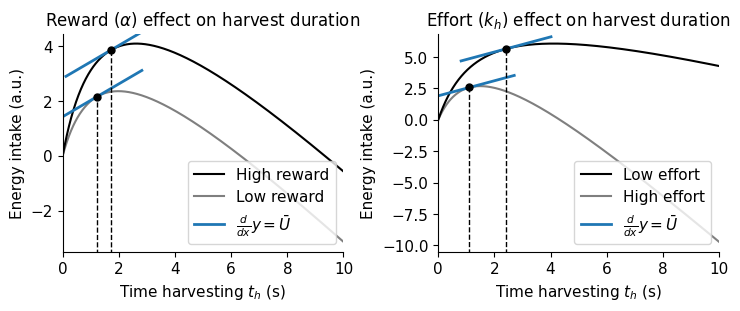

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared sizing & style
# ----------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_W = 7.27   # ~A4 portrait width minus ~0.5" margins each side
FIG_H = 3.0    # short row so two panels fit side-by-side

# ----------------------------
# Functions (unchanged)
# ----------------------------
def available_reward(t, alpha=10.0, beta=0.5):
    t = np.asarray(t, dtype=float)
    return alpha * (1.0 - 1.0 / (1.0 + beta * t))

def effort_cost(t, kh=1.0):
    t = np.asarray(t, dtype=float)
    return -kh * t

def harvest_value(t, alpha=10.0, beta=0.5, kh=1.0):
    # f(t_h) = α(1 − 1/(1 + β t_h)) − kh * t_h
    t = np.asarray(t, dtype=float)
    return available_reward(t, alpha, beta) + effort_cost(t, kh)

# ----------------------------
# Domain & shared slope
# ----------------------------
t_h = np.linspace(0, 10, 800)
U = 0.6  # same slope for all tangents (y' = U)

# ----------------------------
# Parameter sets
# ----------------------------
# Left subplot: Vary REWARD (alpha high/low), keep beta, kh fixed
beta_L = 0.6
kh_L   = 1.0
alpha_hi = 11.0
alpha_lo = 8.0

# Right subplot: Vary EFFORT (kh high/low), keep alpha, beta fixed
alpha_R = 12.0
beta_R  = 0.6
kh_hi = 2.0
kh_lo = 0.6

# ----------------------------
# Helpers for tangency
# ----------------------------
def harvest_tangent_point(alpha, beta, kh, U):
    # solve f'(t) = αβ/(1+βt)^2 − kh = U
    # requirement: αβ > kh + U
    if alpha*beta <= (kh + U):
        return np.nan, np.nan
    t_star = (np.sqrt(alpha*beta / (kh + U)) - 1.0) / beta
    f_star = harvest_value(t_star, alpha, beta, kh)
    return t_star, f_star

def tangent_segment(x0, y0, slope, lo, hi, frac=0.2):
    # a short segment around x0 within [lo, hi]
    halfw = (hi - lo) * frac * 0.8
    xs = np.linspace(max(lo, x0 - halfw), min(hi, x0 + halfw), 100)
    ys = slope * (xs - x0) + y0
    return xs, ys

# ----------------------------
# Compute curves & tangents
# ----------------------------
# Left (reward high/low)
f_L_hi = harvest_value(t_h, alpha_hi, beta_L, kh_L)
f_L_lo = harvest_value(t_h, alpha_lo, beta_L, kh_L)
th_L_hi, fh_L_hi = harvest_tangent_point(alpha_hi, beta_L, kh_L, U)
th_L_lo, fh_L_lo = harvest_tangent_point(alpha_lo, beta_L, kh_L, U)
tx_L_hi, ty_L_hi = tangent_segment(th_L_hi, fh_L_hi, U, t_h.min(), t_h.max())
tx_L_lo, ty_L_lo = tangent_segment(th_L_lo, fh_L_lo, U, t_h.min(), t_h.max())

# Right (effort high/low)
f_R_hi = harvest_value(t_h, alpha_R, beta_R, kh_hi)
f_R_lo = harvest_value(t_h, alpha_R, beta_R, kh_lo)
th_R_hi, fh_R_hi = harvest_tangent_point(alpha_R, beta_R, kh_hi, U)
th_R_lo, fh_R_lo = harvest_tangent_point(alpha_R, beta_R, kh_lo, U)
tx_R_hi, ty_R_hi = tangent_segment(th_R_hi, fh_R_hi, U, t_h.min(), t_h.max())
tx_R_lo, ty_R_lo = tangent_segment(th_R_lo, fh_R_lo, U, t_h.min(), t_h.max())

# ----------------------------
# Plot
# ----------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

# Left: effect of reward (alpha)
axL.plot(t_h, f_L_hi, color='black', alpha=1,  label=rf"High reward")
axL.plot(t_h, f_L_lo, color='black', alpha=0.5, label=rf"Low reward")
axL.plot(tx_L_hi, ty_L_hi, color='tab:blue', linewidth=2, label=r"$\frac{d}{dx}y=\bar{U}$")
axL.plot(tx_L_lo, ty_L_lo, color='tab:blue', linewidth=2, label="_nolegend_")
axL.plot(th_L_hi, fh_L_hi, 'o', color='black', ms=5)
axL.plot(th_L_lo, fh_L_lo, 'o', color='black', ms=5)
axL.plot([th_L_hi, th_L_hi], [min(f_L_hi.min(), f_L_lo.min())-1, fh_L_hi], '--', color='black', lw=1)
axL.plot([th_L_lo, th_L_lo], [min(f_L_hi.min(), f_L_lo.min())-1, fh_L_lo], '--', color='black', lw=1)

axL.set_title(r"Reward ($\alpha$) effect on harvest duration", fontsize=12)
axL.set_xlabel("Time harvesting $t_h$ (s)")
axL.set_ylabel("Energy intake (a.u.)")
axL.set_xlim(t_h.min(), t_h.max())
ymin_L = min(f_L_hi.min(), f_L_lo.min())
ymax_L = max(f_L_hi.max(), f_L_lo.max())
axL.set_ylim(ymin_L - 0.05*(ymax_L-ymin_L), ymax_L + 0.05*(ymax_L-ymin_L))
axL.legend(frameon=True, loc='lower right')

# Right: effect of effort (kh)
axR.plot(t_h, f_R_lo, color='black', alpha=1, label=rf"Low effort")
axR.plot(t_h, f_R_hi, color='black', alpha=.5, label=rf"High effort")
axR.plot(tx_R_lo, ty_R_lo, color='tab:blue', linewidth=2, label=r"$\frac{d}{dx}y=\bar{U}$")
axR.plot(tx_R_hi, ty_R_hi, color='tab:blue', linewidth=2, label="_nolegend_")
axR.plot(th_R_lo, fh_R_lo, 'o', color='black', ms=5)
axR.plot(th_R_hi, fh_R_hi, 'o', color='black', ms=5)
axR.plot([th_R_lo, th_R_lo], [min(f_R_hi.min(), f_R_lo.min())-1, fh_R_lo], '--', color='black', lw=1)
axR.plot([th_R_hi, th_R_hi], [min(f_R_hi.min(), f_R_lo.min())-1, fh_R_hi], '--', color='black', lw=1)

axR.set_title(r"Effort ($k_h$) effect on harvest duration", fontsize=12)
axR.set_xlabel("Time harvesting $t_h$ (s)")
axR.set_ylabel("Energy intake (a.u.)")
axR.set_xlim(t_h.min(), t_h.max())
ymin_R = min(f_R_hi.min(), f_R_lo.min())
ymax_R = max(f_R_hi.max(), f_R_lo.max())
axR.set_ylim(ymin_R - 0.05*(ymax_R-ymin_R), ymax_R + 0.05*(ymax_R-ymin_R))
axR.legend(frameon=True, loc='lower right')

plt.show()

# Optional: export print-ready
fig.savefig("harvest_reward_vs_effort_sameU.png", dpi=300, bbox_inches="tight")


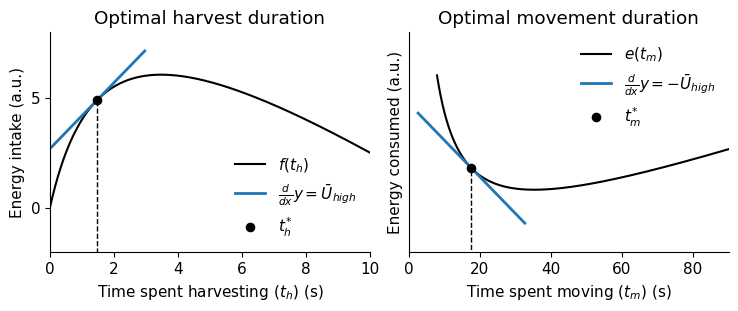

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared sizing & style
# ----------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_W = 7.27   # ~A4 portrait width minus ~0.5" margins each side
FIG_H = 3.0    # short row so two panels fit side-by-side

# ----------------------------
# Original functions (unchanged)
# ----------------------------
def available_reward(t, alpha=10.0, beta=0.5):
    t = np.asarray(t, dtype=float)
    return alpha * (1.0 - 1.0 / (1.0 + beta * t))

def effort_cost(t, kh=1.0):
    t = np.asarray(t, dtype=float)
    return -kh * t

def harvest_value(t, alpha=10.0, beta=0.5, kh=1.0):
    # f(t_h) = α(1 − 1/(1 + β t_h)) − kh * t_h
    t = np.asarray(t, dtype=float)
    return available_reward(t, alpha, beta) + effort_cost(t, kh)

def movement_energy(t_m, a=0.0324, b=0.026244, d=50.0):
    # e(t_m) = a * t_m + b * d^2 / t_m
    t_m = np.asarray(t_m, dtype=float)
    return a * t_m + b * (d ** 2) / t_m

# Parameters (same flavor as before)
alpha, beta, kh = 15.0, 0.5, 1
a, b, d = 0.5, 0.25, 50.0

# Choose a single U to use for both tangents
U1 = 1.5  # energy per second (adjust if you want a steeper/shallower tangent)
U2 = .3

# ----------------------------
# Tangency points from derivative conditions
# Harvest:  f'(t_h*) = U
# Move:     e'(t_m*) = -U
# ----------------------------
# f'(t) = αβ/(1+βt)^2 - kh  => solve for t_h*
th_star_1 = (np.sqrt(alpha*beta / (kh + U1)) - 1.0) / beta
th_star_2 = (np.sqrt(alpha*beta / (kh + U2)) - 1.0) / beta
fh_star_1 = harvest_value(th_star_1, alpha, beta, kh)
fh_star_2 = harvest_value(th_star_2, alpha, beta, kh)

# e'(t) = a - b d^2 / t^2  => set to -U and solve for t_m*
tm_star_1 = np.sqrt(b * d**2 / (a + U1))
tm_star_2 = np.sqrt(b * d**2 / (a + U2))
em_star_1 = movement_energy(tm_star_1, a, b, d)  # this is e(t_m*) (we'll label f_m)
em_star_2 = movement_energy(tm_star_2, a, b, d)

# ----------------------------
# Make data for curves & tangents
# ----------------------------
t_h = np.linspace(0, 10, 800)
t_h_tangent_1 = np.linspace(th_star_1 - 1.5, th_star_1 + 1.5, 10)  # shorter range for tangent
t_h_tangent_2 = np.linspace(th_star_2 - 1.5, th_star_2 + 1.5, 10)  # shorter range for tangent
f_h = harvest_value(t_h, alpha, beta, kh)

t_m = np.linspace(8, 90, 1000)  # avoid t=0 singularity
t_m_tangent_1 = np.linspace(tm_star_1 - 15, tm_star_1 + 15, 10)  # shorter range for tangent
t_m_tangent_2 = np.linspace(tm_star_2 - 15, tm_star_2 + 15, 10)  # shorter range for tangent
f_m = movement_energy(t_m, a, b, d)  # same curve, just labeled f_m

# Tangent lines: y = slope * (x - x0) + y0
harvest_slope_1 = U1
harvest_slope_2 = U2
move_slope_1 = -U1
move_slope_2 = -U2

# Draw tangents over panel ranges
harvest_tangent_1 = harvest_slope_1 * (t_h_tangent_1 - th_star_1) + fh_star_1
harvest_tangent_2 = harvest_slope_2 * (t_h_tangent_2 - th_star_2) + fh_star_2
move_tangent_1 = move_slope_1 * (t_m_tangent_1 - tm_star_1) + em_star_1
move_tangent_2 = move_slope_2 * (t_m_tangent_2 - tm_star_2) + em_star_2

# ----------------------------
# Plot
# ----------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

# Left: Movement duration (show only f_m, with tangent slope -U)
axR.plot(t_m, f_m, color='black', label="$e(t_m)$")                      # f_m(t_m)
axR.plot(t_m_tangent_1, move_tangent_1, linewidth=2, color='tab:blue', label=r"$\frac{d}{dx}y=-\bar{U}_{high}$")  # tangent with slope -U
axR.scatter([tm_star_1], [em_star_1], s=35, color='black', zorder=5, label="$t_m^{*}$")

# line from dot to x axis
axR.plot([tm_star_1, tm_star_1], [-10, em_star_1], color='black', linewidth=1, linestyle='--')

axR.set_title("Optimal movement duration")
axR.set_xlabel("Time spent moving ($t_m$) (s)")
axR.set_ylabel("Energy consumed (a.u.)")

# hide y ticks
axR.set_yticks([])

axR.set_xlim(0, 90)
axR.set_ylim(10, 100)

axR.legend(frameon=False, loc='upper right')

# Right: Harvest duration (show only f(t_h), with tangent slope +U)
axL.plot(t_h, f_h, color='black', label="$f(t_h)$")               # f(t_h)
axL.plot(t_h_tangent_1, harvest_tangent_1, linewidth=2, color='tab:blue', label=r"$\frac{d}{dx}y=\bar{U}_{high}$")  # tangent with slope +U
axL.scatter([th_star_1], [fh_star_1], s=35, color='black', label=r"$t_h^{*}$", zorder=5)
# line from dot to x axis
axL.plot([th_star_1, th_star_1], [-10, fh_star_1], color='black', linewidth=1, linestyle='--')

# hide y ticks
axL.set_yticks([0, 5])

axL.set_title("Optimal harvest duration")
axL.set_xlabel("Time spent harvesting ($t_h$) (s)")
axL.set_ylabel("Energy intake (a.u.)")

axL.set_xlim(0, 10)
axL.set_ylim(0-2, 10-2)

axL.legend(frameon=False, loc='lower right')

plt.show()

# Optional: export print-ready
# fig.savefig("ft_fm_tangents_a4.pdf", bbox_inches="tight")
fig.savefig("ft_fm_tangents_a4.png", dpi=300, bbox_inches="tight")


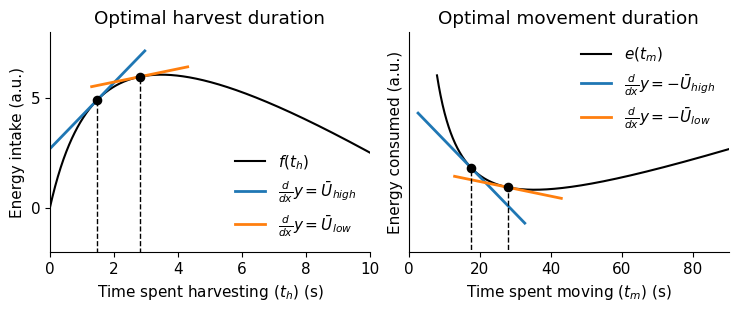

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared sizing & style
# ----------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_W = 7.27   # ~A4 portrait width minus ~0.5" margins each side
FIG_H = 3.0    # short row so two panels fit side-by-side

# ----------------------------
# Original functions (unchanged)
# ----------------------------
def available_reward(t, alpha=10.0, beta=0.5):
    t = np.asarray(t, dtype=float)
    return alpha * (1.0 - 1.0 / (1.0 + beta * t))

def effort_cost(t, kh=1.0):
    t = np.asarray(t, dtype=float)
    return -kh * t

def harvest_value(t, alpha=10.0, beta=0.5, kh=1.0):
    # f(t_h) = α(1 − 1/(1 + β t_h)) − kh * t_h
    t = np.asarray(t, dtype=float)
    return available_reward(t, alpha, beta) + effort_cost(t, kh)

def movement_energy(t_m, a=0.0324, b=0.026244, d=50.0):
    # e(t_m) = a * t_m + b * d^2 / t_m
    t_m = np.asarray(t_m, dtype=float)
    return a * t_m + b * (d ** 2) / t_m

# Parameters (same flavor as before)
alpha, beta, kh = 15.0, 0.5, 1
a, b, d = 0.5, 0.25, 50.0

# Choose a single U to use for both tangents
U1 = 1.5  # energy per second (adjust if you want a steeper/shallower tangent)
U2 = .3

# ----------------------------
# Tangency points from derivative conditions
# Harvest:  f'(t_h*) = U
# Move:     e'(t_m*) = -U
# ----------------------------
# f'(t) = αβ/(1+βt)^2 - kh  => solve for t_h*
th_star_1 = (np.sqrt(alpha*beta / (kh + U1)) - 1.0) / beta
th_star_2 = (np.sqrt(alpha*beta / (kh + U2)) - 1.0) / beta
fh_star_1 = harvest_value(th_star_1, alpha, beta, kh)
fh_star_2 = harvest_value(th_star_2, alpha, beta, kh)

# e'(t) = a - b d^2 / t^2  => set to -U and solve for t_m*
tm_star_1 = np.sqrt(b * d**2 / (a + U1))
tm_star_2 = np.sqrt(b * d**2 / (a + U2))
em_star_1 = movement_energy(tm_star_1, a, b, d)  # this is e(t_m*) (we'll label f_m)
em_star_2 = movement_energy(tm_star_2, a, b, d)

# ----------------------------
# Make data for curves & tangents
# ----------------------------
t_h = np.linspace(0, 10, 800)
t_h_tangent_1 = np.linspace(th_star_1 - 1.5, th_star_1 + 1.5, 10)  # shorter range for tangent
t_h_tangent_2 = np.linspace(th_star_2 - 1.5, th_star_2 + 1.5, 10)  # shorter range for tangent
f_h = harvest_value(t_h, alpha, beta, kh)

t_m = np.linspace(8, 90, 1000)  # avoid t=0 singularity
t_m_tangent_1 = np.linspace(tm_star_1 - 15, tm_star_1 + 15, 10)  # shorter range for tangent
t_m_tangent_2 = np.linspace(tm_star_2 - 15, tm_star_2 + 15, 10)  # shorter range for tangent
f_m = movement_energy(t_m, a, b, d)  # same curve, just labeled f_m

# Tangent lines: y = slope * (x - x0) + y0
harvest_slope_1 = U1
harvest_slope_2 = U2
move_slope_1 = -U1
move_slope_2 = -U2

# Draw tangents over panel ranges
harvest_tangent_1 = harvest_slope_1 * (t_h_tangent_1 - th_star_1) + fh_star_1
harvest_tangent_2 = harvest_slope_2 * (t_h_tangent_2 - th_star_2) + fh_star_2
move_tangent_1 = move_slope_1 * (t_m_tangent_1 - tm_star_1) + em_star_1
move_tangent_2 = move_slope_2 * (t_m_tangent_2 - tm_star_2) + em_star_2

# ----------------------------
# Plot
# ----------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

# Left: Movement duration (show only f_m, with tangent slope -U)
axR.plot(t_m, f_m, color='black', label="$e(t_m)$")                      # f_m(t_m)
axR.plot(t_m_tangent_1, move_tangent_1, linewidth=2, color='tab:blue', label=r"$\frac{d}{dx}y=-\bar{U}_{high}$")  # tangent with slope -U
axR.plot(t_m_tangent_2, move_tangent_2, linewidth=2, color='tab:orange', label=r"$\frac{d}{dx}y=-\bar{U}_{low}$")  # tangent with slope -U
axR.scatter([tm_star_1], [em_star_1], s=35, color='black', zorder=5)
axR.scatter([tm_star_2], [em_star_2], s=35, color='black', zorder=5)

# line from dot to x axis
axR.plot([tm_star_1, tm_star_1], [-10, em_star_1], color='black', linewidth=1, linestyle='--')
axR.plot([tm_star_2, tm_star_2], [-10, em_star_2], color='black', linewidth=1, linestyle='--')

axR.set_title("Optimal movement duration")
axR.set_xlabel("Time spent moving ($t_m$) (s)")
axR.set_ylabel("Energy consumed (a.u.)")

# hide y ticks
axR.set_yticks([])

axR.set_xlim(0, 90)
axR.set_ylim(10, 100)

axR.legend(frameon=False, loc='upper right')

# Right: Harvest duration (show only f(t_h), with tangent slope +U)
axL.plot(t_h, f_h, color='black', label="$f(t_h)$")               # f(t_h)
axL.plot(t_h_tangent_1, harvest_tangent_1, linewidth=2, color='tab:blue', label=r"$\frac{d}{dx}y=\bar{U}_{high}$")  # tangent with slope +U
axL.plot(t_h_tangent_2, harvest_tangent_2, linewidth=2, color='tab:orange', label=r"$\frac{d}{dx}y=\bar{U}_{low}$")  # tangent with slope +U
axL.scatter([th_star_1], [fh_star_1], s=35, color='black',  zorder=5)
axL.scatter([th_star_2], [fh_star_2], s=35, color='black', zorder=5)
# line from dot to x axis
axL.plot([th_star_1, th_star_1], [-10, fh_star_1], color='black', linewidth=1, linestyle='--')
axL.plot([th_star_2, th_star_2], [-10, fh_star_2], color='black', linewidth=1, linestyle='--')

# hide y ticks
axL.set_yticks([0, 5])

axL.set_title("Optimal harvest duration")
axL.set_xlabel("Time spent harvesting ($t_h$) (s)")
axL.set_ylabel("Energy intake (a.u.)")

axL.set_xlim(0, 10)
axL.set_ylim(0-2, 10-2)

axL.legend(frameon=False, loc='lower right')

plt.show()

# Optional: export print-ready
# fig.savefig("ft_fm_tangents_a4.pdf", bbox_inches="tight")
fig.savefig("ft_fm_double_tangents_a4.png", dpi=300, bbox_inches="tight")


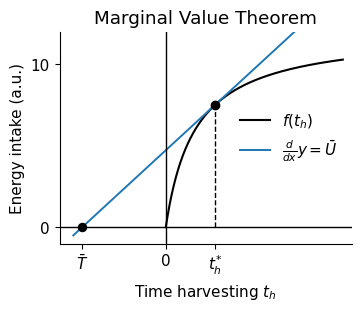

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared sizing & style
# ----------------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_W = 3.5   # ~A4 portrait width minus ~0.5" margins each side
FIG_H = 3.0

# ----------------------------
# Harvest model
# ----------------------------
def available_reward(t, alpha=10.0, beta=0.5):
    t = np.asarray(t, dtype=float)
    return alpha * (1.0 - 1.0 / (1.0 + beta * t))

def effort_cost(t, kh=1.0):
    t = np.asarray(t, dtype=float)
    return -kh * t

def harvest_value(t, alpha=10.0, beta=0.5, kh=1.0):
    # f(t_h) = α(1 − 1/(1 + β t_h)) − kh * t_h
    t = np.asarray(t, dtype=float)
    return available_reward(t, alpha, beta) + effort_cost(t, kh)

# ----------------------------
# Parameters and slope
# ----------------------------
alpha, beta, kh = 12.0, 0.6, 0   # tune if you like
U =    1                          # slope of the tangent (y' = U)

# Tangency point from f'(t) = U, with f'(t) = αβ/(1+βt)^2 − kh
if alpha*beta <= (kh + U):
    raise ValueError("Choose params with alpha*beta > kh + U to have a valid tangency.")

t_star = (np.sqrt(alpha*beta / (kh + U)) - 1.0) / beta
f_star = harvest_value(t_star, alpha, beta, kh)

# Tangent: y = U (t - t*) + f*
# x-axis crossing where y=0 -> t_x = t* - f*/U
t_x = t_star - f_star / U

# ----------------------------
# Plot domain
# ----------------------------
# Curve only for t in [0, 10], but make axes wide enough so the tangent crosses visibly.
t_curve = np.linspace(0, 10, 800)
f_curve = harvest_value(t_curve, alpha, beta, kh)

# Axes limits that include the intercept and the curve comfortably
pad = 0.5
xmin = min(0.0, t_x) - pad
xmax = max(10.0, t_star, t_x) + pad

# Build a long tangent segment spanning whole axes range
t_tan = np.linspace(xmin, xmax, 400)
f_tan = U * (t_tan - t_star) + f_star

# For neat y-lims, include both curve and tangent values
y_all = np.concatenate([f_curve, f_tan])
ymin = y_all.min()
ymax = y_all.max()
yr = ymax - ymin
ymin -= 0.08 * yr
ymax += 0.08 * yr

# ----------------------------
# Draw
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(FIG_W, FIG_H), constrained_layout=True)

ax.plot(t_curve, f_curve, color='black', label=r"$f(t_h)$")
ax.plot(t_tan,   f_tan,   color='tab:blue', lw=1.4, label=r"$\frac{d}{dx}y=\bar{U}$")
# line from tangency point to x axis
ax.plot([t_star, t_star], [0, f_star], '--', color='black', lw=1)

# Tangency point
ax.plot(t_star, f_star, 'o', color='black', ms=6, zorder=5)

# x-axis and x-intercept marker
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.plot(t_x, 0, marker='o', color='black', ms=5, mew=1.8, zorder=6)

# ADD TEXT ANNOTATIONS: tm*, f_m* ax xticks
ax.set_xticks([0, t_star, t_x])
ax.set_xticklabels([0, r"$t_h^{*}$", r"$\bar{T}$"])

# Cosmetics
ax.set_xlim(-6, xmax)
ax.set_ylim(-1, alpha)

ax.set_yticks([0, 10])

ax.set_xlabel("Time harvesting $t_h$")
ax.set_ylabel("Energy intake (a.u.)")
ax.set_title("Marginal Value Theorem")
ax.legend(frameon=False, loc="best")

plt.show()

# Optional: save
# fig.savefig("harvest_single_tangent.pdf", bbox_inches="tight")
fig.savefig("harvest_single_tangent.png", dpi=300, bbox_inches="tight")
